# Paper / Chunk Distribution per Species

Shows how many documents and chunks were ingested per species across five evaluated testcases.
Each testcase is saved as its own PNG in `figures/`.

In [1]:
import json
import pathlib
import pandas as pd
import matplotlib.pyplot as plt

BASE = pathlib.Path('.')
FIGURES = pathlib.Path('figures')
FIGURES.mkdir(exist_ok=True)

RUNS = {
    'TC1 - Subterranean':    'logs_graph/2026-05-28_14-42-28-testcase1-4acc25f6',
    'TC3 - Color-change':    'logs_graph/2026-05-29_08-27-35-testcase3-07ac65a2',
    'TC4 - Electroreception':'logs_graph/2026-05-29_21-21-18-testcase4-3c69530e',
    'TC6 - Hypoxia':         'logs_graph/2026-05-31_09-36-51-testcase6-a2005130',
    'SPATC1L (production)':  'logs_graphs',
}

TC_COLORS = {
    'TC1 - Subterranean':    '#4c72b0',
    'TC3 - Color-change':    '#dd8452',
    'TC4 - Electroreception':'#55a868',
    'TC6 - Hypoxia':         '#c44e52',
    'SPATC1L (production)':  '#8172b3',
}

TC_SLUGS = {
    'TC1 - Subterranean':    'tc1_subterranean',
    'TC3 - Color-change':    'tc3_color_change',
    'TC4 - Electroreception':'tc4_electroreception',
    'TC6 - Hypoxia':         'tc6_hypoxia',
    'SPATC1L (production)':  'spatc1l_production',
}

rows = []
for testcase, rel_path in RUNS.items():
    run01 = BASE / rel_path / 'runs' / 'run_01'
    if not run01.exists():
        print(f'WARNING: {run01} not found')
        continue
    for sp_dir in sorted(run01.iterdir()):
        if not sp_dir.is_dir():
            continue
        docs_file = sp_dir / 'ingested_docs.json'
        idx_file  = sp_dir / 'graph_indexer_summary.json'
        n_docs, n_chunks = None, None
        if docs_file.exists():
            try:
                n_docs = len(json.loads(docs_file.read_text()))
            except Exception:
                pass
        if idx_file.exists():
            try:
                n_chunks = json.loads(idx_file.read_text()).get('chunks_seen')
            except Exception:
                pass
        sp_label = sp_dir.name.replace('_', ' ').capitalize()
        rows.append({'testcase': testcase, 'species': sp_label,
                     'docs': n_docs, 'chunks': n_chunks})

df = pd.DataFrame(rows)
print(f'{len(df)} species total')
df

34 species total


,testcase,species,docs,chunks
0,TC1 - Subterranean,Chrysochloris asiatica,18,634
1,TC1 - Subterranean,Condylura cristata,12,393
2,TC1 - Subterranean,Heterocephalus glaber,9,300
3,TC1 - Subterranean,Nannospalax ehrenbergi,21,667
4,TC3 - Color-change,Dryophytes versicolor,10,516
5,TC3 - Color-change,Furcifer pardalis,11,358
6,TC3 - Color-change,Octopus vulgaris,9,719
7,TC3 - Color-change,Panulirus cygnus,6,225
8,TC4 - Electroreception,Ambystoma mexicanum,13,877
9,TC4 - Electroreception,Carcharodon carcharias,11,616


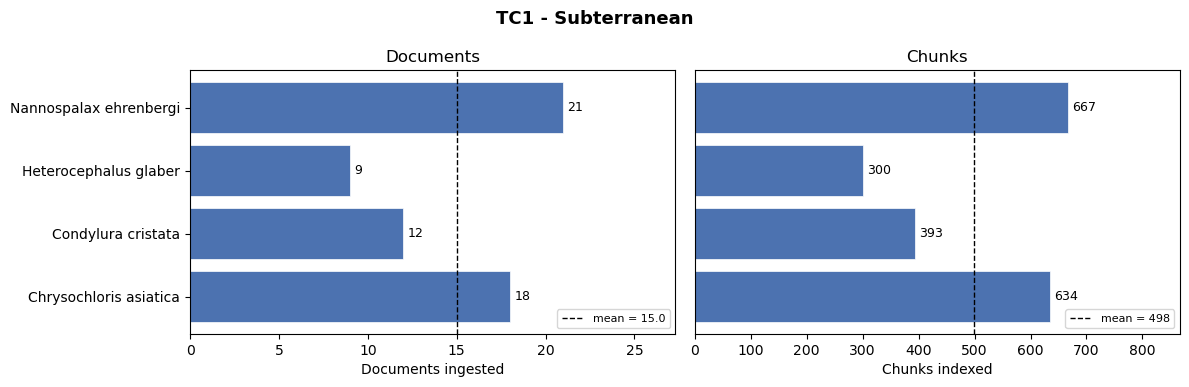

Saved: figures/tc1_subterranean.png


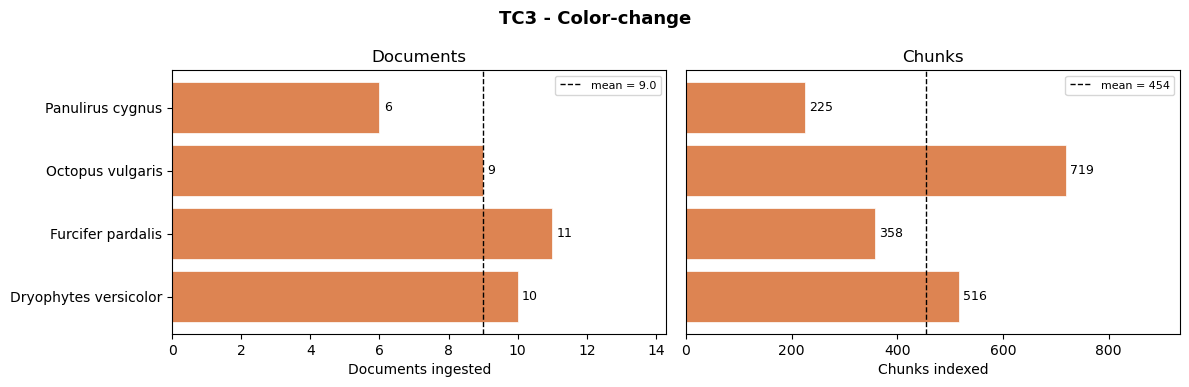

Saved: figures/tc3_color_change.png


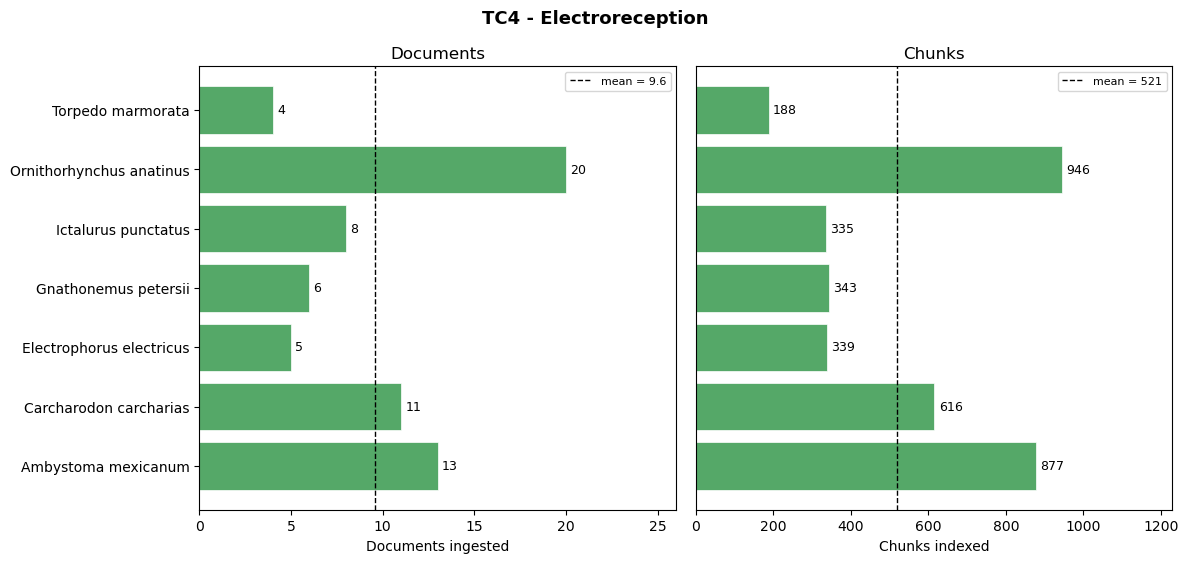

Saved: figures/tc4_electroreception.png


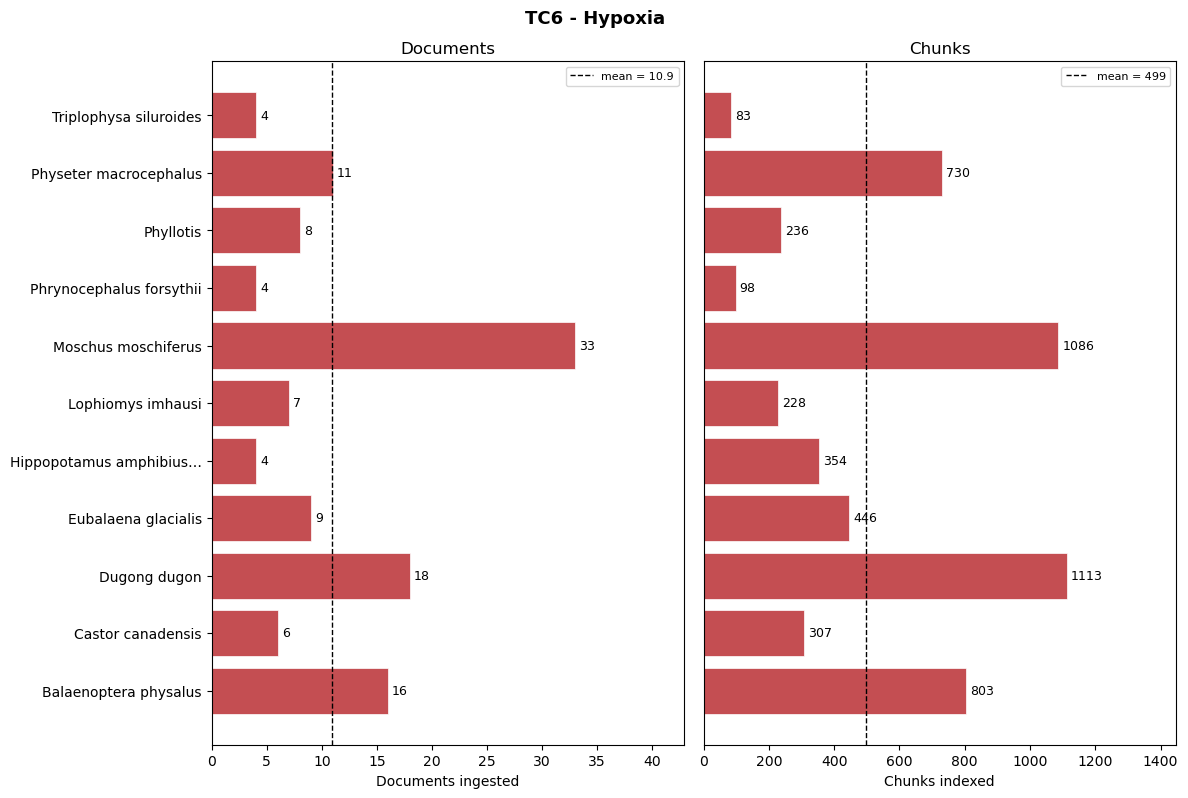

Saved: figures/tc6_hypoxia.png


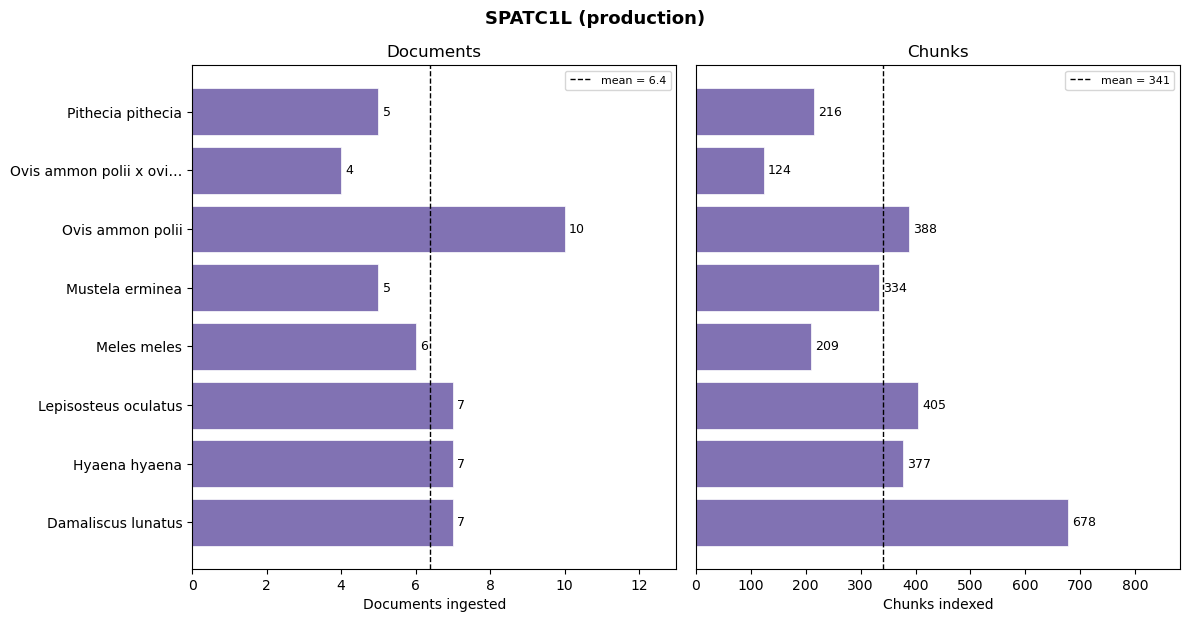

Saved: figures/spatc1l_production.png


In [2]:
# ── One PNG per testcase: docs (left) + chunks (right) ──

for tc, slug in TC_SLUGS.items():
    grp = df[df['testcase'] == tc].copy()
    color = TC_COLORS[tc]
    n = len(grp)
    sp_labels = [s if len(s) <= 24 else s[:22] + '…' for s in grp['species']]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, max(3, n * 0.6 + 1.5)))
    fig.suptitle(tc, fontsize=13, fontweight='bold')

    # Docs — species names shown here
    bars1 = ax1.barh(sp_labels, grp['docs'], color=color, edgecolor='white', linewidth=0.5)
    ax1.bar_label(bars1, padding=3, fontsize=9)
    ax1.axvline(grp['docs'].mean(), color='black', linestyle='--', linewidth=1,
                label=f'mean = {grp["docs"].mean():.1f}')
    ax1.set_xlabel('Documents ingested')
    ax1.set_title('Documents')
    ax1.set_xlim(0, grp['docs'].max() * 1.3)
    ax1.legend(fontsize=8)

    # Chunks — no species names (shared with left chart)
    bars2 = ax2.barh(sp_labels, grp['chunks'], color=color, edgecolor='white', linewidth=0.5)
    ax2.bar_label(bars2, padding=3, fontsize=9)
    ax2.axvline(grp['chunks'].mean(), color='black', linestyle='--', linewidth=1,
                label=f'mean = {grp["chunks"].mean():.0f}')
    ax2.set_xlabel('Chunks indexed')
    ax2.set_title('Chunks')
    ax2.set_xlim(0, grp['chunks'].max() * 1.3)
    ax2.set_yticks([])
    ax2.legend(fontsize=8)

    plt.tight_layout()
    out = FIGURES / f'{slug}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

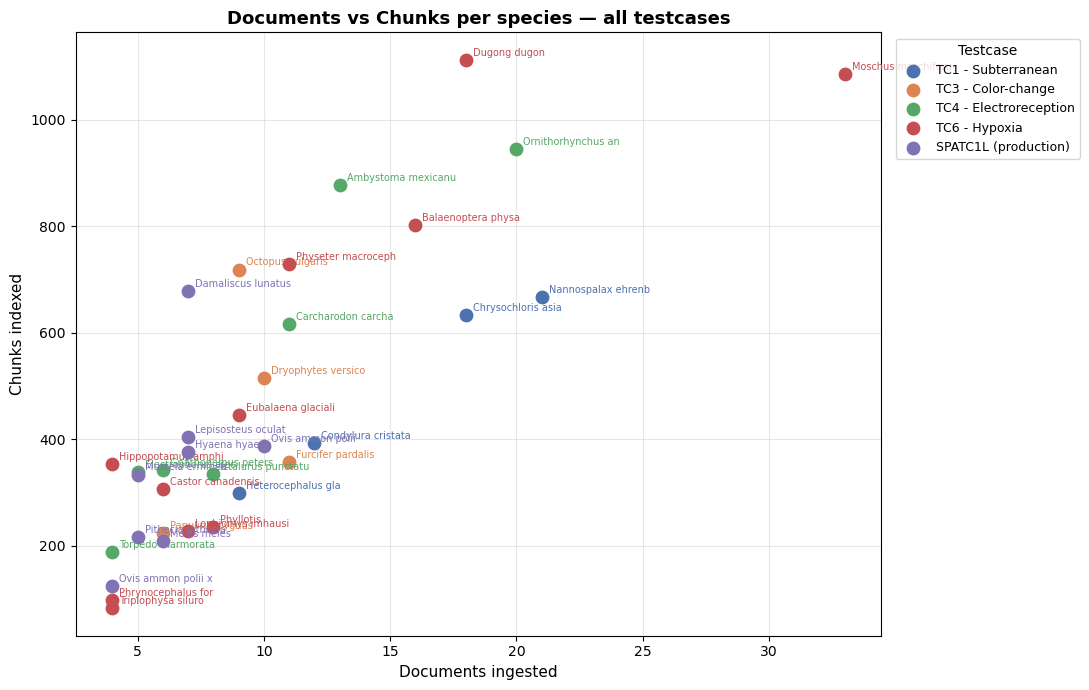

Saved: figures/scatter_all.png


In [3]:
# ── Scatter: docs vs chunks, all testcases ──

fig, ax = plt.subplots(figsize=(11, 7))

for tc in RUNS:
    grp = df[df['testcase'] == tc]
    color = TC_COLORS[tc]
    ax.scatter(grp['docs'], grp['chunks'], color=color, s=80, zorder=3, label=tc)
    for _, row in grp.iterrows():
        ax.annotate(row['species'][:18], (row['docs'], row['chunks']),
                    textcoords='offset points', xytext=(5, 3),
                    fontsize=7, color=color)

ax.set_xlabel('Documents ingested', fontsize=11)
ax.set_ylabel('Chunks indexed', fontsize=11)
ax.set_title('Documents vs Chunks per species — all testcases', fontsize=13, fontweight='bold')
ax.legend(title='Testcase', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
out = FIGURES / 'scatter_all.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [4]:
# ── Summary statistics ──

summary = df.groupby('testcase')[['docs', 'chunks']].agg(['min', 'max', 'mean']).round(1)
summary.columns = ['docs_min', 'docs_max', 'docs_mean', 'chunks_min', 'chunks_max', 'chunks_mean']
summary['docs_imbalance_ratio'] = df.groupby('testcase')['docs'].apply(lambda x: round(x.max() / x.min(), 1))

print('Per-testcase statistics:')
print(summary.to_string())
print()
print(f'Total species: {len(df)}')
print(f'Docs  — min: {df["docs"].min()}  max: {df["docs"].max()}  mean: {df["docs"].mean():.1f}')
print(f'Species with < 7 docs:  {(df["docs"] < 7).sum()} ({(df["docs"] < 7).mean()*100:.0f}%)')
print(f'Species with < 10 docs: {(df["docs"] < 10).sum()} ({(df["docs"] < 10).mean()*100:.0f}%)')

Per-testcase statistics:
                        docs_min  docs_max  docs_mean  chunks_min  chunks_max  chunks_mean  docs_imbalance_ratio
testcase                                                                                                        
SPATC1L (production)           4        10        6.4         124         678        341.4                   2.5
TC1 - Subterranean             9        21       15.0         300         667        498.5                   2.3
TC3 - Color-change             6        11        9.0         225         719        454.5                   1.8
TC4 - Electroreception         4        20        9.6         188         946        520.6                   5.0
TC6 - Hypoxia                  4        33       10.9          83        1113        498.5                   8.2

Total species: 34
Docs  — min: 4  max: 33  mean: 9.8
Species with < 7 docs:  12 (35%)
Species with < 10 docs: 21 (62%)
